# Track 1 / 2 / 3 / 4 — Full Analysis

Builds on `analysis_track124.ipynb` by adding **Track 3: Llama-3.1-8B** scores.

New variables:
- `management_optimism` — forward-looking sentiment (0–10)
- `guidance_specificity` — how concrete is the guidance (0–10)
- `uncertainty_hedging` — density of hedging language (0–10)
- `risk_framing` — how risks are framed vs opportunities (0–10)

All four are z-score standardised before regression.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import glob
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA = 'data'

## 1. Load Llama Scores (Track 3)

In [2]:
# Load all 12 result files
records = []
for path in sorted(glob.glob(f'{DATA}/llm_out/results_*.jsonl')):
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            if d['scores'] is not None:
                records.append({
                    'gvkey': d['gvkey'],
                    'fyear': int(d['fyear']),
                    'llm_optimism':    d['scores']['management_optimism'],
                    'llm_specificity': d['scores']['guidance_specificity'],
                    'llm_hedging':     d['scores']['uncertainty_hedging'],
                    'llm_risk':        d['scores']['risk_framing'],
                })

llama = pd.DataFrame(records)
print(f'Llama scores: {len(llama):,} firm-years')
print(f'Parse success rate: {len(llama)/11269:.1%}')
llama.describe().round(2)

Llama scores: 11,269 firm-years
Parse success rate: 100.0%


,fyear,llm_optimism,llm_specificity,llm_hedging,llm_risk
count,11269.00,11269.00,11269.00,11269.00,11268.00
mean,2015.17,5.72,3.28,4.33,3.10
std,3.14,1.71,2.55,2.28,1.95
min,2010.00,0.00,0.00,0.00,0.00
25%,2012.00,5.00,0.00,3.00,2.00
50%,2015.00,5.00,4.00,4.00,2.00
75%,2018.00,7.00,6.00,6.00,4.00
max,2020.00,9.00,9.00,10.00,10.00


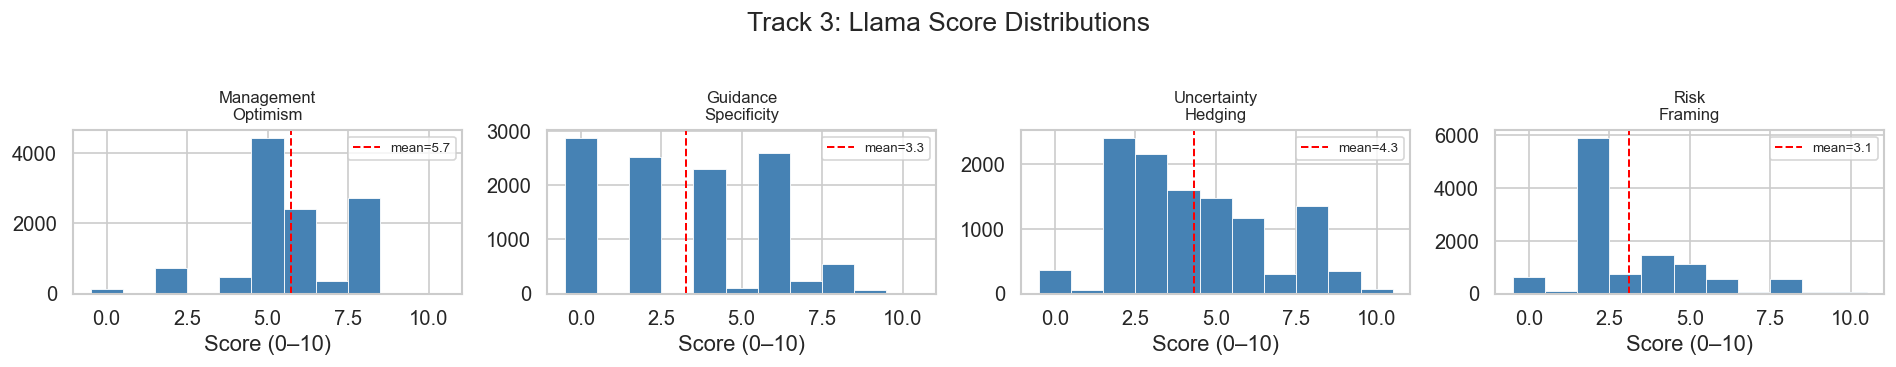

In [3]:
# Distribution of the four Llama dimensions
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
labels = ['Management\nOptimism', 'Guidance\nSpecificity',
          'Uncertainty\nHedging', 'Risk\nFraming']
cols   = ['llm_optimism', 'llm_specificity', 'llm_hedging', 'llm_risk']

for ax, col, label in zip(axes, cols, labels):
    ax.hist(llama[col], bins=11, range=(-0.5, 10.5),
            color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Score (0–10)')
    ax.axvline(llama[col].mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'mean={llama[col].mean():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Track 3: Llama Score Distributions', y=1.02)
plt.tight_layout()
plt.show()

## 2. Load Analysis Panel (from Track 124 notebook)

In [4]:
# Load the pre-built panel with CAR + Track 1/2/4 features
panel = pd.read_parquet(f'{DATA}/analysis_panel.parquet')
panel['fyear'] = panel['fyear'].astype(int)
print(f'Panel: {len(panel):,} firm-years')
panel.columns.tolist()

Panel: 9,735 firm-years


['gvkey',
 'permno',
 'cik',
 'ticker',
 'sic',
 'fyear',
 'datadate',
 'date_filed',
 'rdq',
 'accession_no',
 's3_key',
 'mda_len',
 'log_assets',
 'log_mktcap',
 'bm_ratio',
 'roa',
 'leverage',
 'car_1_1',
 'car_3_3',
 'lm_negative',
 'lm_positive',
 'lm_uncertainty',
 'lm_litigious',
 'lm_strong_modal',
 'lm_weak_modal',
 'lm_total_words',
 'lm_net_sent',
 'lm_tone',
 'lm_uncertainty_pct',
 'fb_positive',
 'fb_negative',
 'fb_neutral',
 'fb_net',
 'fb_n_chunks',
 'embed_cos_sim',
 'embed_novelty',
 'lm_tone_z',
 'lm_uncertainty_pct_z',
 'fb_net_z',
 'embed_novelty_z',
 'log_assets_z',
 'log_mktcap_z',
 'bm_ratio_z',
 'roa_z',
 'leverage_z',
 'sic2']

## 3. Merge Llama Scores

In [5]:
df = panel.merge(llama, on=['gvkey', 'fyear'], how='left')
print(f'Merged: {len(df):,} rows')
print(f'Llama scores available: {df["llm_optimism"].notna().sum():,}')
df[['llm_optimism', 'llm_specificity', 'llm_hedging', 'llm_risk']].describe().round(2)

Merged: 9,735 rows
Llama scores available: 9,735


,llm_optimism,llm_specificity,llm_hedging,llm_risk
count,9735.00,9735.00,9735.00,9735.00
mean,5.80,3.42,4.41,3.16
std,1.67,2.51,2.22,1.91
min,0.00,0.00,0.00,0.00
25%,5.00,2.00,3.00,2.00
50%,6.00,4.00,4.00,2.00
75%,8.00,6.00,6.00,4.00
max,9.00,9.00,10.00,10.00


## 4. Z-score Standardise All Features

In [6]:
TEXT_124  = ['lm_tone', 'lm_uncertainty_pct', 'fb_net', 'embed_novelty']
TEXT_LLM  = ['llm_optimism', 'llm_specificity', 'llm_hedging', 'llm_risk']
CONTROLS  = ['log_assets', 'log_mktcap', 'bm_ratio', 'roa', 'leverage']

ALL_VARS = TEXT_124 + TEXT_LLM + CONTROLS
for col in ALL_VARS:
    if col in df.columns:
        df[f'{col}_z'] = stats.zscore(df[col], nan_policy='omit')

df['sic2']  = df['sic'].astype(str).str[:2]
df['fyear'] = df['fyear'].astype(str)

REG_VARS = ['car_1_1'] + [f'{c}_z' for c in ALL_VARS]
df_reg = df.dropna(subset=REG_VARS).copy()
print(f'Full regression sample (Track 1234): {len(df_reg):,} firm-years')

Full regression sample (Track 1234): 9,735 firm-years


## 5. Correlation: Llama vs Other Tracks

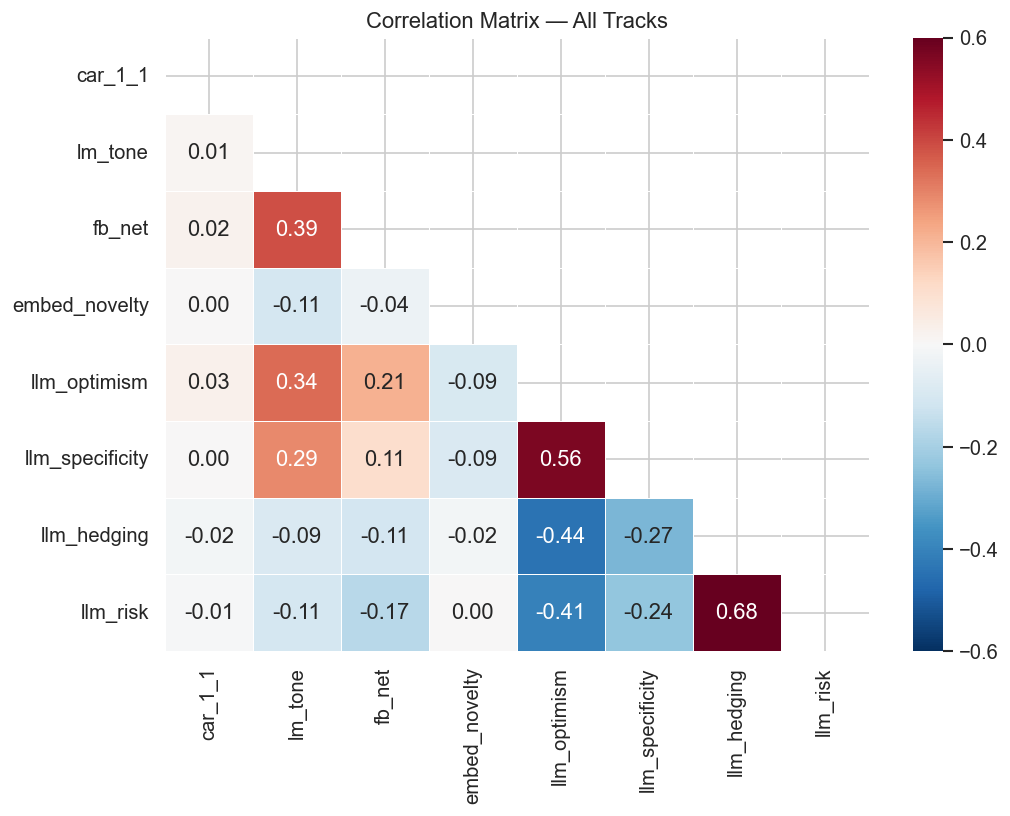

In [7]:
corr_vars = ['car_1_1', 'lm_tone', 'fb_net', 'embed_novelty',
             'llm_optimism', 'llm_specificity', 'llm_hedging', 'llm_risk']
corr = df_reg[[v for v in corr_vars if v in df_reg.columns]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — All Tracks')
plt.tight_layout()
plt.show()

## 6. OLS Regressions — Four Tracks + Horse-Race

Each track is estimated **separately** first to show its standalone predictive power,
then all tracks enter together in a **horse-race** (Model C) to reveal which signal
survives head-to-head competition. Controls and FE are identical across all models.

In [8]:
CTRL_Z = ' + '.join(f'{c}_z' for c in CONTROLS)
FE     = 'C(fyear) + C(sic2)'

def run_ols(formula, data):
    return smf.ols(formula, data=data).fit(
        cov_type='cluster', cov_kwds={'groups': data['gvkey']})

def show_model(model, name, text_vars):
    rows = []
    for var in text_vars:
        if var not in model.params:
            continue
        p = model.pvalues[var]
        stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
        rows.append({'Variable': var,
                     'Coef': round(model.params[var], 4),
                     'SE':   round(model.bse[var], 4),
                     't':    round(model.tvalues[var], 2),
                     'p':    round(p, 4),
                     'Sig':  stars})
    tbl = pd.DataFrame(rows).set_index('Variable')
    print(f'\n── {name}  |  R²={model.rsquared:.4f}  N={int(model.nobs):,} ──')
    print(tbl.to_string())
    return tbl


In [9]:
# ── M1: Track 1 — LM Dictionary (word-bag baseline) ─────────────────────────
# Oldest approach: count positive/negative financial words in Loughran-McDonald lexicon.
# Captures surface-level tone via word frequency, no context or semantics.
lm_vars = 'lm_tone_z + lm_uncertainty_pct_z'
mM1 = run_ols(f'car_1_1 ~ {lm_vars} + {CTRL_Z} + {FE}', df_reg)
tM1 = show_model(mM1, 'M1: Track 1 — LM Dictionary only',
                 ['lm_tone_z', 'lm_uncertainty_pct_z'])



── M1: Track 1 — LM Dictionary only  |  R²=0.0195  N=9,735 ──
                        Coef      SE     t       p Sig
Variable                                              
lm_tone_z             0.0014  0.0007  1.96  0.0496  **
lm_uncertainty_pct_z  0.0004  0.0007  0.58  0.5589    


In [10]:
# ── M2: Track 2 — FinBERT neural sentiment ────────────────────────────────────
# Fine-tuned BERT model for financial text. Understands context and negation.
# Outputs sentence-level positive/negative/neutral probabilities, aggregated to filing level.
mM2 = run_ols(f'car_1_1 ~ fb_net_z + {CTRL_Z} + {FE}', df_reg)
tM2 = show_model(mM2, 'M2: Track 2 — FinBERT only', ['fb_net_z'])



── M2: Track 2 — FinBERT only  |  R²=0.0198  N=9,735 ──
            Coef      SE     t       p Sig
Variable                                  
fb_net_z  0.0018  0.0007  2.51  0.0119  **


In [11]:
# ── M3: Track 3 — Llama-3.1-8B multidimensional scoring ─────────────────────
# LLM scores four dimensions: management optimism, guidance specificity,
# uncertainty hedging, risk framing — dimensions not captured by sentiment alone.
llm_vars = 'llm_optimism_z + llm_specificity_z + llm_hedging_z + llm_risk_z'
mM3 = run_ols(f'car_1_1 ~ {llm_vars} + {CTRL_Z} + {FE}', df_reg)
tM3 = show_model(mM3, 'M3: Track 3 — Llama only',
                 ['llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z'])



── M3: Track 3 — Llama only  |  R²=0.0202  N=9,735 ──
                     Coef      SE     t       p  Sig
Variable                                            
llm_optimism_z     0.0023  0.0009  2.68  0.0073  ***
llm_specificity_z -0.0011  0.0009 -1.29  0.1965     
llm_hedging_z     -0.0015  0.0010 -1.61  0.1084     
llm_risk_z         0.0014  0.0009  1.50  0.1327     


In [12]:
# ── M4: Track 4 — Sentence-BERT semantic novelty ─────────────────────────────
# Measures year-over-year CHANGE in MD&A content via cosine distance of SBERT embeddings.
# Captures information novelty (how different this year's filing is from last year's),
# orthogonal to sentiment — a firm can be optimistic but say nothing new.
mM4 = run_ols(f'car_1_1 ~ embed_novelty_z + {CTRL_Z} + {FE}', df_reg)
tM4 = show_model(mM4, 'M4: Track 4 — SBERT Novelty only', ['embed_novelty_z'])



── M4: Track 4 — SBERT Novelty only  |  R²=0.0192  N=9,735 ──
                   Coef      SE     t       p Sig
Variable                                         
embed_novelty_z  0.0003  0.0006  0.47  0.6396    


In [13]:
# ── MC: Horse-Race — All tracks compete simultaneously ───────────────────────
# All 8 NLP variables enter together. A variable that remains significant here
# carries information ORTHOGONAL to everything else — the cleanest test of
# whether each approach captures something unique.
all_vars = (f'{lm_vars} + fb_net_z + embed_novelty_z + {llm_vars}')
mC = run_ols(f'car_1_1 ~ {all_vars} + {CTRL_Z} + {FE}', df_reg)
tC = show_model(mC, 'MC: Horse-Race — All Tracks 1+2+3+4',
                ['lm_tone_z','lm_uncertainty_pct_z','fb_net_z','embed_novelty_z',
                 'llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z'])



── MC: Horse-Race — All Tracks 1+2+3+4  |  R²=0.0208  N=9,735 ──
                        Coef      SE     t       p Sig
Variable                                              
lm_tone_z             0.0006  0.0008  0.79  0.4278    
lm_uncertainty_pct_z  0.0006  0.0007  0.91  0.3626    
fb_net_z              0.0014  0.0008  1.86  0.0626   *
embed_novelty_z       0.0004  0.0006  0.58  0.5636    
llm_optimism_z        0.0020  0.0009  2.29  0.0218  **
llm_specificity_z    -0.0012  0.0009 -1.34  0.1807    
llm_hedging_z        -0.0017  0.0010 -1.73  0.0829   *
llm_risk_z            0.0015  0.0009  1.61  0.1076    


In [14]:
# ── MD: Robustness — CAR[-3,+3] in horse-race ────────────────────────────────
df_rob = df.dropna(subset=['car_3_3'] + [f'{c}_z' for c in ALL_VARS]).copy()
mD = run_ols(f'car_3_3 ~ {all_vars} + {CTRL_Z} + {FE}', df_rob)
tD = show_model(mD, 'MD: Robustness — CAR[-3,+3] (all tracks)',
                ['lm_tone_z','lm_uncertainty_pct_z','fb_net_z','embed_novelty_z',
                 'llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z'])



── MD: Robustness — CAR[-3,+3] (all tracks)  |  R²=0.0196  N=9,735 ──
                        Coef      SE     t       p Sig
Variable                                              
lm_tone_z             0.0012  0.0008  1.41  0.1582    
lm_uncertainty_pct_z  0.0006  0.0007  0.85  0.3980    
fb_net_z              0.0004  0.0009  0.50  0.6145    
embed_novelty_z       0.0009  0.0008  1.21  0.2260    
llm_optimism_z        0.0022  0.0010  2.13  0.0334  **
llm_specificity_z    -0.0008  0.0010 -0.79  0.4295    
llm_hedging_z        -0.0019  0.0011 -1.71  0.0880   *
llm_risk_z            0.0012  0.0011  1.13  0.2598    



R² Comparison — Standalone vs Horse-Race
                         Track  R² (%)     N
Model                                       
M1: LM Dictionary           T1   1.950  9735
M2: FinBERT                 T2   1.978  9735
M3: Llama                   T3   2.024  9735
M4: SBERT Novelty           T4   1.919  9735
MC: Horse-Race (all)  T1+2+3+4   2.084  9735


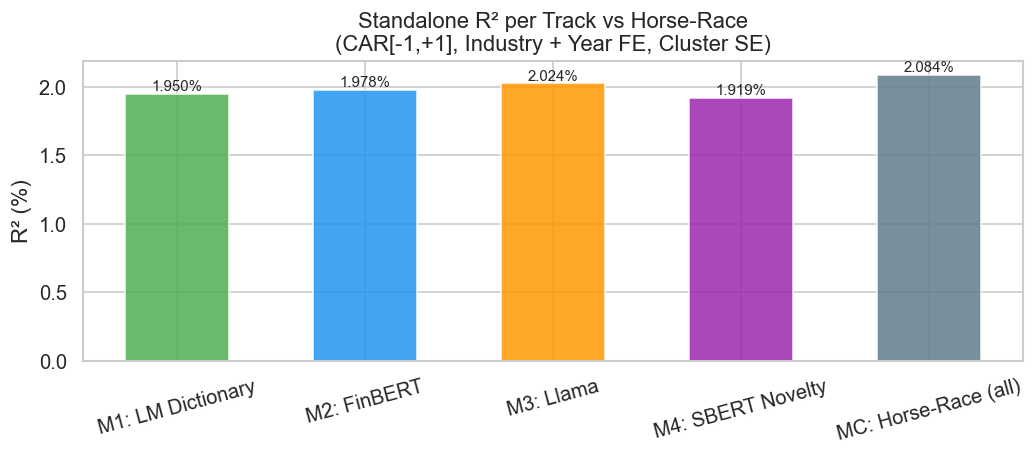

In [15]:
# ── R² Summary: standalone vs horse-race ─────────────────────────────────────
r2_tbl = pd.DataFrame([
    {'Model': 'M1: LM Dictionary',    'Track': 'T1',       'R²': mM1.rsquared, 'N': int(mM1.nobs)},
    {'Model': 'M2: FinBERT',          'Track': 'T2',       'R²': mM2.rsquared, 'N': int(mM2.nobs)},
    {'Model': 'M3: Llama',            'Track': 'T3',       'R²': mM3.rsquared, 'N': int(mM3.nobs)},
    {'Model': 'M4: SBERT Novelty',    'Track': 'T4',       'R²': mM4.rsquared, 'N': int(mM4.nobs)},
    {'Model': 'MC: Horse-Race (all)', 'Track': 'T1+2+3+4', 'R²': mC.rsquared,  'N': int(mC.nobs)},
]).set_index('Model')
r2_tbl['R² (%)'] = (r2_tbl['R²'] * 100).round(3)

print("\nR² Comparison — Standalone vs Horse-Race")
print(r2_tbl[['Track','R² (%)','N']].to_string())

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4CAF50','#2196F3','#FF9800','#9C27B0','#607D8B']
bars = ax.bar(r2_tbl.index, r2_tbl['R² (%)'], color=colors, alpha=0.85, width=0.55)
for bar, (_, row) in zip(bars, r2_tbl.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{row['R² (%)']:.3f}%", ha='center', va='bottom', fontsize=9)
ax.set_ylabel('R² (%)')
ax.set_title('Standalone R² per Track vs Horse-Race\n(CAR[-1,+1], Industry + Year FE, Cluster SE)')
ax.tick_params(axis='x', labelrotation=15)
plt.tight_layout()
plt.show()


## 7. Incremental F-test: Does Track 3 Add Explanatory Power?

In [16]:
# ── Incremental F-test: Does Track 3 (Llama) add explanatory power? ──────────
# Restricted model: T1 + T2 + T4 (everything except Llama)
# Unrestricted model: MC (all tracks)
# H0: β_llm_optimism = β_llm_specificity = β_llm_hedging = β_llm_risk = 0

from scipy import stats as scipy_stats

# Re-fit the restricted model (T1+T2+T4) inline just for this test
t124_vars_ft = 'lm_tone_z + lm_uncertainty_pct_z + fb_net_z + embed_novelty_z'
mRestr = run_ols(f'car_1_1 ~ {t124_vars_ft} + {CTRL_Z} + {FE}', df_reg)

RSS_R  = mRestr.ssr
RSS_U  = mC.ssr
df_R   = mRestr.df_resid
df_U   = mC.df_resid
q      = df_R - df_U     # = 4 Llama variables

F_stat = ((RSS_R - RSS_U) / q) / (RSS_U / df_U)
p_val  = 1 - scipy_stats.f.cdf(F_stat, q, df_U)

print("Incremental F-test: Does adding Track 3 (Llama) improve fit over T1+T2+T4?")
print(f"  Restricted  (T1+T2+T4): R² = {mRestr.rsquared:.4f},  RSS = {RSS_R:.4f}")
print(f"  Unrestricted (all):     R² = {mC.rsquared:.4f},  RSS = {RSS_U:.4f}")
print(f"  Restrictions q = {int(q)}")
print(f"  F({int(q)}, {int(df_U)}) = {F_stat:.3f},  p = {p_val:.4f}")
star = '***' if p_val<0.01 else '**' if p_val<0.05 else '*' if p_val<0.10 else '(n.s.)'
print(f"  → {'Llama adds significant power beyond T1+T2+T4' if p_val<0.10 else 'No significant gain from adding Llama'}  {star}")

print()
# Reverse test: does T1+T2+T4 add to Llama?
RSS_R2 = mM3.ssr
df_R2  = mM3.df_resid
q2     = df_R2 - df_U
F2     = ((RSS_R2 - RSS_U) / q2) / (RSS_U / df_U)
p2     = 1 - scipy_stats.f.cdf(F2, q2, df_U)
print("Reverse test: Does adding T1+T2+T4 improve fit over Llama alone?")
print(f"  F({int(q2)}, {int(df_U)}) = {F2:.3f},  p = {p2:.4f}")
star2 = '***' if p2<0.01 else '**' if p2<0.05 else '*' if p2<0.10 else '(n.s.)'
print(f"  → {'T1+T2+T4 add over Llama' if p2<0.10 else 'No significant gain from T1+T2+T4 given Llama'}  {star2}")


Incremental F-test: Does adding Track 3 (Llama) improve fit over T1+T2+T4?
  Restricted  (T1+T2+T4): R² = 0.0199,  RSS = 43.9178
  Unrestricted (all):     R² = 0.0208,  RSS = 43.8770
  Restrictions q = 4
  F(4, 9651) = 2.243,  p = 0.0619
  → Llama adds significant power beyond T1+T2+T4  *

Reverse test: Does adding T1+T2+T4 improve fit over Llama alone?
  F(4, 9651) = 1.465,  p = 0.2099
  → No significant gain from T1+T2+T4 given Llama  (n.s.)


## 8. Coefficient Plot — All Tracks (Model C)

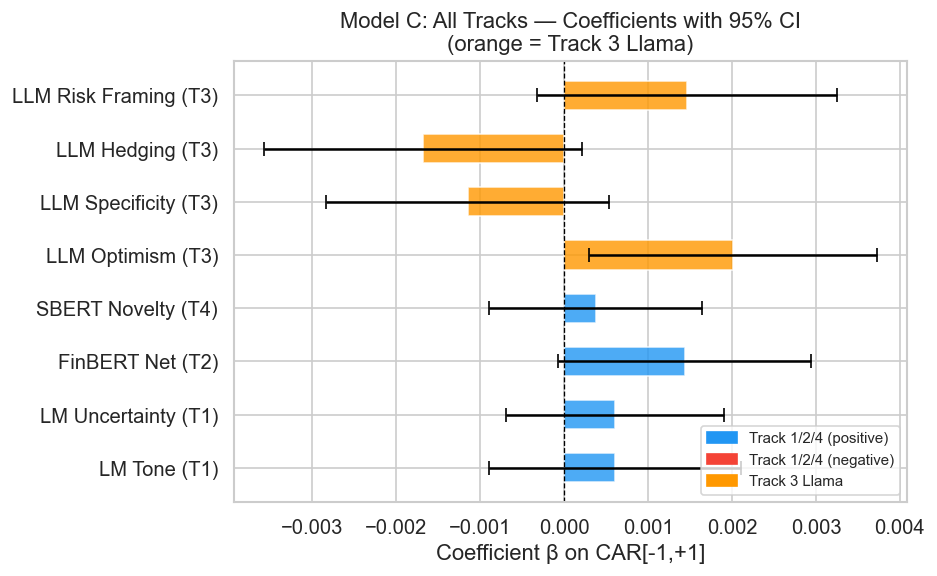

In [17]:
plot_vars = [
    ('lm_tone_z',           'LM Tone (T1)'),
    ('lm_uncertainty_pct_z','LM Uncertainty (T1)'),
    ('fb_net_z',            'FinBERT Net (T2)'),
    ('embed_novelty_z',     'SBERT Novelty (T4)'),
    ('llm_optimism_z',      'LLM Optimism (T3)'),
    ('llm_specificity_z',   'LLM Specificity (T3)'),
    ('llm_hedging_z',       'LLM Hedging (T3)'),
    ('llm_risk_z',          'LLM Risk Framing (T3)'),
]

vars_   = [v for v, _ in plot_vars if v in mC.params]
labels_ = [l for v, l in plot_vars if v in mC.params]
coefs_  = mC.params[vars_]
cis_    = mC.conf_int().loc[vars_]
colors_ = ['#2196F3' if c > 0 else '#F44336' for c in coefs_]

# Mark Track 3 variables
track3 = [v.startswith('llm') for v in vars_]
face_colors = ['#FF9800' if t else c for t, c in zip(track3, colors_)]

fig, ax = plt.subplots(figsize=(8, 5))
for i, (var, label) in enumerate(zip(vars_, labels_)):
    color = '#FF9800' if var.startswith('llm') else ('#2196F3' if coefs_[var] > 0 else '#F44336')
    ax.barh(i, coefs_[var], color=color, alpha=0.8, height=0.55)
    ax.errorbar(coefs_[var], i,
                xerr=[[coefs_[var] - cis_.loc[var, 0]],
                      [cis_.loc[var, 1] - coefs_[var]]],
                fmt='none', color='black', capsize=4, linewidth=1.5)

ax.set_yticks(range(len(labels_)))
ax.set_yticklabels(labels_)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient β on CAR[-1,+1]')
ax.set_title('Model C: All Tracks — Coefficients with 95% CI\n(orange = Track 3 Llama)')

from matplotlib.patches import Patch
legend = [Patch(color='#2196F3', label='Track 1/2/4 (positive)'),
          Patch(color='#F44336', label='Track 1/2/4 (negative)'),
          Patch(color='#FF9800', label='Track 3 Llama')]
ax.legend(handles=legend, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 9. CAR by Llama Score Quintile

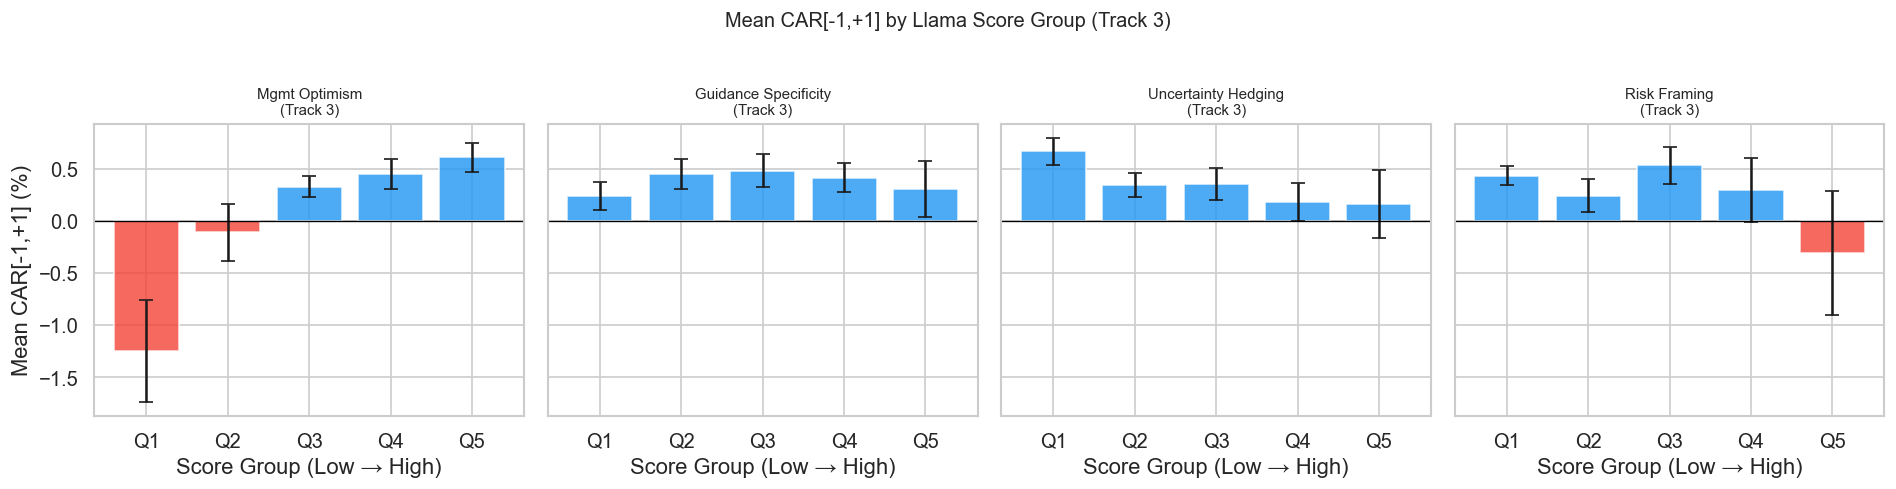

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
llm_cols   = ['llm_optimism', 'llm_specificity', 'llm_hedging', 'llm_risk']
llm_labels = ['Mgmt Optimism\n(Track 3)', 'Guidance Specificity\n(Track 3)',
               'Uncertainty Hedging\n(Track 3)', 'Risk Framing\n(Track 3)']

for ax, var, label in zip(axes, llm_cols, llm_labels):
    df_plot = df_reg.dropna(subset=[var, 'car_1_1']).copy()
    # 用整数值直接分组，不用 qcut
    df_plot['score_grp'] = pd.cut(df_plot[var], bins=5, include_lowest=True)
    means = df_plot.groupby('score_grp', observed=True)['car_1_1'].mean() * 100
    sems  = df_plot.groupby('score_grp', observed=True)['car_1_1'].sem()  * 100
    x_labels = [f'Q{i+1}' for i in range(len(means))]
    colors = ['#F44336' if m < 0 else '#2196F3' for m in means]
    ax.bar(range(len(means)), means, yerr=sems, color=colors, alpha=0.8,
           edgecolor='white', capsize=4)
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(x_labels)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Score Group (Low → High)')
    if ax == axes[0]:
        ax.set_ylabel('Mean CAR[-1,+1] (%)')

plt.suptitle('Mean CAR[-1,+1] by Llama Score Group (Track 3)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 10. Save Full Results

In [19]:
all_results = []
for tbl, name in [(tM1,'M1: LM Dict'), (tM2,'M2: FinBERT'),
                  (tM3,'M3: Llama'),   (tM4,'M4: SBERT'),
                  (tC,'MC: Horse-Race'), (tD,'MD: CAR[-3,+3]')]:
    t = tbl.copy()
    t['Model'] = name
    all_results.append(t.reset_index())

out = pd.concat(all_results, ignore_index=True)
out.to_csv(f'{DATA}/regression_results_1234.csv', index=False)
print('✓ Saved regression_results_1234.csv')

df_reg.to_parquet(f'{DATA}/analysis_panel_1234.parquet', index=False)
print('✓ Saved analysis_panel_1234.parquet')


✓ Saved regression_results_1234.csv
✓ Saved analysis_panel_1234.parquet


## 11. Multicollinearity Check (VIF)

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

text_z_cols = ['lm_tone_z', 'lm_uncertainty_pct_z', 'fb_net_z', 'embed_novelty_z',
               'llm_optimism_z', 'llm_specificity_z', 'llm_hedging_z', 'llm_risk_z']

X_vif = df_reg[text_z_cols].dropna().assign(const=1.0)
vif_df = pd.DataFrame({
    'Variable': text_z_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(len(text_z_cols))]
}).set_index('Variable').round(2)

print("VIF (all < 10 is acceptable; < 5 is good; < 2 is excellent)")
print(vif_df.to_string())
print(f"\nMax VIF: {vif_df['VIF'].max():.2f}  — {'✓ No multicollinearity concern' if vif_df['VIF'].max() < 5 else '⚠ Check collinearity'}")


VIF (all < 10 is acceptable; < 5 is good; < 2 is excellent)
                       VIF
Variable                  
lm_tone_z             1.35
lm_uncertainty_pct_z  1.09
fb_net_z              1.21
embed_novelty_z       1.03
llm_optimism_z        1.84
llm_specificity_z     1.50
llm_hedging_z         1.99
llm_risk_z            1.92

Max VIF: 1.99  — ✓ No multicollinearity concern


## 12. Causal Identification — First Difference

**Motivation:** OLS with industry+year FE still leaves room for time-varying, firm-specific confounders (e.g., a firm on a long-term upward trend always files optimistic MD&As *and* beats expectations).

**First-Difference (FD) estimator:** Instead of regressing levels on levels, we regress  
`CAR_{i,t}` on **Δ(NLP score)_{i,t} = NLP_{i,t} − NLP_{i,t−1}`.

By taking first differences we remove *all* time-invariant firm heterogeneity — identical to a within-firm (company FE) estimator, but avoids the negative between-R² we saw with entity dummies.

**Interpretation:** A firm whose management optimism *increased* relative to last year should predict a higher market reaction — controlling for year effects.


In [21]:
# ── First Difference Setup ───────────────────────────────────────────────────
df_fd = df_reg.copy()
df_fd['fyear'] = df_fd['fyear'].astype(int)
df_fd = df_fd.sort_values(['gvkey', 'fyear'])

# Variables to difference (predictors only — car_1_1 is the annual CAR outcome)
diff_cols = ['fb_net', 'llm_optimism', 'llm_specificity', 'llm_hedging', 'llm_risk',
             'lm_tone', 'lm_uncertainty_pct', 'embed_novelty',
             'log_assets', 'log_mktcap', 'bm_ratio', 'roa', 'leverage']

for col in diff_cols:
    df_fd[f'd_{col}'] = df_fd.groupby('gvkey')[col].diff()

# Drop rows where key differenced predictors or the outcome are missing
key_diff = ['fb_net', 'llm_optimism', 'llm_hedging', 'lm_tone', 'embed_novelty',
            'log_assets', 'log_mktcap', 'bm_ratio', 'roa', 'leverage']
df_fd = df_fd.dropna(subset=[f'd_{c}' for c in key_diff] + ['car_1_1'])
print(f'First-difference sample: {len(df_fd):,} firm-year transitions')
print(f'Unique firms: {df_fd["gvkey"].nunique():,}')

# Z-score the differenced variables
for col in diff_cols:
    df_fd[f'd_{col}_z'] = stats.zscore(df_fd[f'd_{col}'], nan_policy='omit')

df_fd['fyear_str'] = df_fd['fyear'].astype(str)


First-difference sample: 8,642 firm-year transitions
Unique firms: 1,077


In [22]:
# ── First Difference Regressions ─────────────────────────────────────────────
d_llm  = 'd_llm_optimism_z + d_llm_specificity_z + d_llm_hedging_z + d_llm_risk_z'
d_t124 = 'd_lm_tone_z + d_lm_uncertainty_pct_z + d_fb_net_z + d_embed_novelty_z'
d_ctrl = 'd_log_assets_z + d_log_mktcap_z + d_bm_ratio_z + d_roa_z + d_leverage_z'
FE_fd  = 'C(fyear_str)'   # year FE only (firm FE already absorbed by differencing)

def run_fd(formula, data):
    return smf.ols(formula, data=data).fit(
        cov_type='cluster', cov_kwds={'groups': data['gvkey']})

# FD-A: Llama only
mFD_A = run_fd(f'car_1_1 ~ {d_llm} + {d_ctrl} + {FE_fd}', df_fd)
tFD_A = show_model(mFD_A, 'FD-A: First Diff — Llama only',
                   ['d_llm_optimism_z','d_llm_specificity_z',
                    'd_llm_hedging_z','d_llm_risk_z'])

# FD-B: All tracks
mFD_B = run_fd(f'car_1_1 ~ {d_llm} + {d_t124} + {d_ctrl} + {FE_fd}', df_fd)
tFD_B = show_model(mFD_B, 'FD-B: First Diff — All Tracks',
                   ['d_lm_tone_z','d_lm_uncertainty_pct_z','d_fb_net_z','d_embed_novelty_z',
                    'd_llm_optimism_z','d_llm_specificity_z',
                    'd_llm_hedging_z','d_llm_risk_z'])



── FD-A: First Diff — Llama only  |  R²=0.0074  N=8,642 ──
                       Coef      SE     t       p Sig
Variable                                             
d_llm_optimism_z     0.0005  0.0008  0.57  0.5671    
d_llm_specificity_z  0.0007  0.0008  0.95  0.3444    
d_llm_hedging_z     -0.0012  0.0009 -1.39  0.1638    
d_llm_risk_z         0.0007  0.0008  0.85  0.3969    

── FD-B: First Diff — All Tracks  |  R²=0.0086  N=8,642 ──
                          Coef      SE     t       p Sig
Variable                                                
d_lm_tone_z             0.0006  0.0008  0.74  0.4583    
d_lm_uncertainty_pct_z -0.0008  0.0007 -1.14  0.2533    
d_fb_net_z              0.0019  0.0008  2.50  0.0123  **
d_embed_novelty_z       0.0006  0.0007  0.92  0.3567    
d_llm_optimism_z        0.0001  0.0009  0.13  0.8936    
d_llm_specificity_z     0.0007  0.0008  0.82  0.4094    
d_llm_hedging_z        -0.0011  0.0009 -1.29  0.1973    
d_llm_risk_z            0.0009  0.0008  1.0

## 13. Causal Identification — IV (Leave-One-Out Industry-Year Mean)

**Instrument construction:**  
For firm *i* in industry *s* and year *t*, the instrument is the *leave-one-out* mean of other firms' LLM optimism in the same 2-digit SIC × year cell:

$$Z_{i,s,t} = \frac{1}{N_{s,t}-1} \sum_{j \neq i, j \in s} \text{LLM\_optimism}_{j,t}$$

**Validity argument:**  
- *Relevance:* Firms in the same industry face the same macro/sector shocks, so peer optimism is correlated with own optimism (testable via first-stage F-stat > 10).  
- *Exclusion:* Peer firms' MD&A disclosures affect THIS firm's CAR only through information about the industry environment, not directly through firm-specific news.

**Implementation:** Manual 2SLS (first-stage OLS → second-stage OLS on fitted values).


In [23]:
# ── Build Leave-One-Out Instruments ─────────────────────────────────────────
df_iv = df_reg.copy()
df_iv['fyear'] = df_iv['fyear'].astype(int)

for col in ['llm_optimism', 'fb_net', 'lm_tone']:
    grp_sum   = df_iv.groupby(['sic2', 'fyear'])[col].transform('sum')
    grp_count = df_iv.groupby(['sic2', 'fyear'])[col].transform('count')
    df_iv[f'{col}_loo'] = (grp_sum - df_iv[col]) / (grp_count - 1)

# Check instrument relevance (first-stage correlation)
from scipy.stats import pearsonr
valid = df_iv[['llm_optimism', 'llm_optimism_loo']].dropna()
r, p  = pearsonr(valid['llm_optimism'], valid['llm_optimism_loo'])
print(f"LOO instrument — Pearson r = {r:.3f}  (p = {p:.2e})")
print(f"Industry-year cells: {df_iv.groupby(['sic2','fyear']).ngroups:,}")

# Standardise instruments
for col in ['llm_optimism', 'fb_net', 'lm_tone']:
    df_iv[f'{col}_loo_z'] = stats.zscore(df_iv[f'{col}_loo'], nan_policy='omit')

df_iv['fyear_str'] = df_iv['fyear'].astype(str)

iv_req = ['car_1_1', 'llm_optimism_z', 'llm_optimism_loo_z',
          'fb_net_z', 'lm_tone_z', 'embed_novelty_z',
          'log_assets_z', 'log_mktcap_z', 'bm_ratio_z', 'roa_z', 'leverage_z']
df_iv2 = df_iv.dropna(subset=iv_req).copy()
print(f"\nIV sample: {len(df_iv2):,} firm-years, {df_iv2['gvkey'].nunique():,} firms")


LOO instrument — Pearson r = 0.181  (p = 1.03e-72)
Industry-year cells: 617

IV sample: 9,714 firm-years, 1,093 firms


In [24]:
# ── Manual 2SLS ──────────────────────────────────────────────────────────────
CTRL_Z  = 'log_assets_z + log_mktcap_z + bm_ratio_z + roa_z + leverage_z'
FE_iv   = 'C(fyear_str) + C(sic2)'

# First stage: regress LLM optimism on instrument + controls + FE
fs = smf.ols(
    f'llm_optimism_z ~ llm_optimism_loo_z + {CTRL_Z} + {FE_iv}',
    data=df_iv2
).fit()

df_iv2['llm_optimism_hat'] = fs.fittedvalues

# First-stage F-stat (instrument strength)
from statsmodels.stats.anova import anova_lm
fs_restricted = smf.ols(
    f'llm_optimism_z ~ {CTRL_Z} + {FE_iv}',
    data=df_iv2
).fit()
f_stat = ((fs_restricted.ssr - fs.ssr) / 1) / (fs.ssr / fs.df_resid)
print(f"First-stage F-stat (instrument strength): {f_stat:.2f}")
print(f"  (Rule of thumb: F > 10 indicates strong instrument)")
print(f"  First-stage R²: {fs.rsquared:.4f}")

# Second stage: regress CAR on fitted llm_optimism + other controls
mIV = smf.ols(
    f'car_1_1 ~ llm_optimism_hat + fb_net_z + lm_tone_z + embed_novelty_z + {CTRL_Z} + {FE_iv}',
    data=df_iv2
).fit(cov_type='cluster', cov_kwds={'groups': df_iv2['gvkey']})

print()
tIV = show_model(mIV, 'MIV: 2SLS (LOO Industry-Year Instrument)',
                 ['llm_optimism_hat', 'fb_net_z', 'lm_tone_z', 'embed_novelty_z'])
print("\nNote: 2SLS SEs are conservative — use as directional evidence.")


First-stage F-stat (instrument strength): 116.16
  (Rule of thumb: F > 10 indicates strong instrument)
  First-stage R²: 0.1215


── MIV: 2SLS (LOO Industry-Year Instrument)  |  R²=0.0208  N=9,714 ──
                    Coef      SE     t       p Sig
Variable                                          
llm_optimism_hat -0.0022  0.0077 -0.28  0.7778    
fb_net_z          0.0016  0.0008  2.11  0.0352  **
lm_tone_z         0.0008  0.0007  1.03  0.3019    
embed_novelty_z   0.0004  0.0006  0.60  0.5494    

Note: 2SLS SEs are conservative — use as directional evidence.


## 14. Causal Identification Summary

In [25]:
print("=" * 70)
print("CAUSAL IDENTIFICATION SUMMARY")
print("=" * 70)
print()
print("Strategy 1: First Difference (FD-B, all tracks)")
print("-" * 50)
for var in ['d_llm_optimism_z', 'd_fb_net_z', 'd_lm_tone_z']:
    if var in mFD_B.params:
        p    = mFD_B.pvalues[var]
        star = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
        print(f"  {var:30s}  β={mFD_B.params[var]:+.4f}  p={p:.4f} {star}")
print(f"  R² = {mFD_B.rsquared:.4f}  N = {int(mFD_B.nobs):,}")
print()
print("Strategy 2: IV — 2SLS with LOO industry-year instrument")
print("-" * 50)
for var in ['llm_optimism_hat', 'fb_net_z']:
    if var in mIV.params:
        p    = mIV.pvalues[var]
        star = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
        print(f"  {var:30s}  β={mIV.params[var]:+.4f}  p={p:.4f} {star}")
print(f"  R² = {mIV.rsquared:.4f}  N = {int(mIV.nobs):,}")
print()
print("Benchmark: OLS horse-race (Model C)")
print("-" * 50)
for var in ['llm_optimism_z', 'fb_net_z']:
    p    = mC.pvalues[var]
    star = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
    print(f"  {var:30s}  β={mC.params[var]:+.4f}  p={p:.4f} {star}")
print(f"  R² = {mC.rsquared:.4f}  N = {int(mC.nobs):,}")


CAUSAL IDENTIFICATION SUMMARY

Strategy 1: First Difference (FD-B, all tracks)
--------------------------------------------------
  d_llm_optimism_z                β=+0.0001  p=0.8936 
  d_fb_net_z                      β=+0.0019  p=0.0123 **
  d_lm_tone_z                     β=+0.0006  p=0.4583 
  R² = 0.0086  N = 8,642

Strategy 2: IV — 2SLS with LOO industry-year instrument
--------------------------------------------------
  llm_optimism_hat                β=-0.0022  p=0.7778 
  fb_net_z                        β=+0.0016  p=0.0352 **
  R² = 0.0208  N = 9,714

Benchmark: OLS horse-race (Model C)
--------------------------------------------------
  llm_optimism_z                  β=+0.0020  p=0.0218 **
  fb_net_z                        β=+0.0014  p=0.0626 *
  R² = 0.0208  N = 9,735


## 15. Robustness Check — Event Date: 10-K Filing Date (date_filed)

**Motivation:** The baseline uses `rdq` (earnings announcement date) as the event,
but the 10-K MD&A is filed weeks later. Markets cannot react to text they haven't
seen yet. This robustness check aligns the event window with the actual filing date,
so the NLP features and the market reaction refer to the same information release.

**Expectation:** If MD&A text carries *incremental* information beyond the earnings
number (already priced at rdq), we should still see significant coefficients here.
If coefficients disappear, the baseline results were driven by the earnings number
itself, not the textual content.


Filing-date CARs: 9,735 firm-years
       car_filed_1_1  car_filed_3_3
count      9735.0000      9735.0000
mean          0.0023         0.0034
std           0.0459         0.0627
min          -0.4657        -0.5964
25%          -0.0143        -0.0222
50%           0.0007         0.0020
75%           0.0177         0.0292
max           0.5364         0.8099


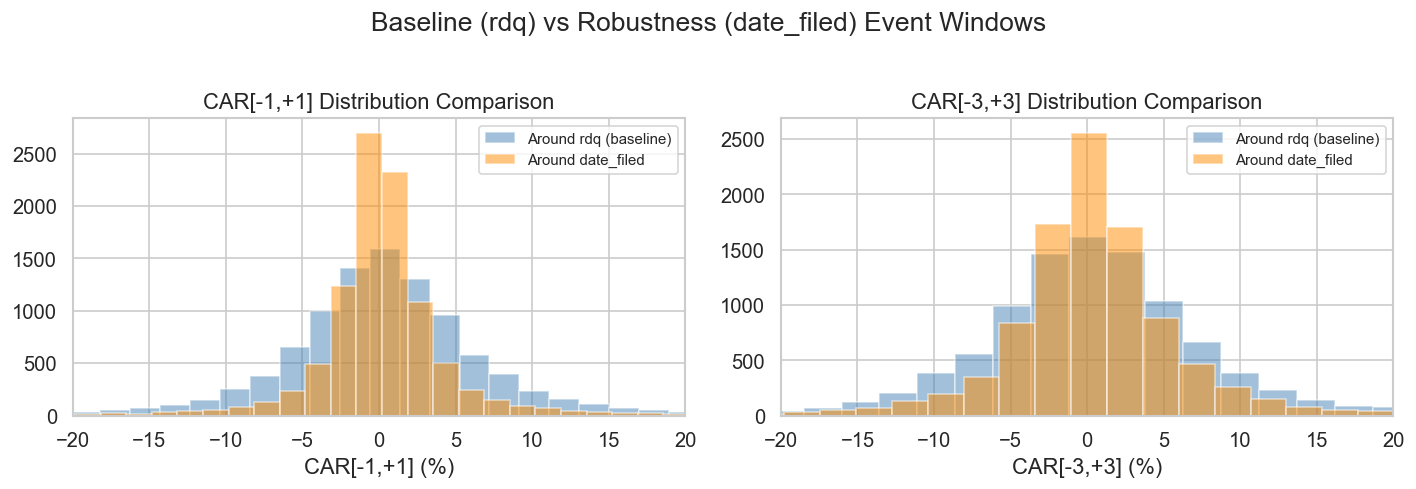

In [26]:
# Load filing-date CARs
car_filed = pd.read_parquet(f'{DATA}/car_filing_date.parquet')
car_filed['fyear'] = car_filed['fyear'].astype(int)
print(f"Filing-date CARs: {len(car_filed):,} firm-years")
print(car_filed[['car_filed_1_1','car_filed_3_3']].describe().round(4))

# Compare distributions: rdq-based vs filing-date-based
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (col_rdq, col_filed, label) in zip(axes, [
    ('car_1_1', 'car_filed_1_1', 'CAR[-1,+1]'),
    ('car_3_3', 'car_filed_3_3', 'CAR[-3,+3]'),
]):
    _car_filed_str = car_filed.copy()
    _car_filed_str['fyear'] = _car_filed_str['fyear'].astype(str)
    merged_plot = df_reg[['gvkey','fyear', col_rdq]].merge(
        _car_filed_str[['gvkey','fyear', col_filed]], on=['gvkey','fyear'], how='inner')
    ax.hist(merged_plot[col_rdq]*100,   bins=60, alpha=0.5, label='Around rdq (baseline)', color='steelblue')
    ax.hist(merged_plot[col_filed]*100, bins=60, alpha=0.5, label='Around date_filed',      color='darkorange')
    ax.set_xlabel(f'{label} (%)')
    ax.set_title(f'{label} Distribution Comparison')
    ax.legend(fontsize=9)
    ax.set_xlim(-20, 20)
plt.suptitle('Baseline (rdq) vs Robustness (date_filed) Event Windows', y=1.02)
plt.tight_layout()
plt.show()


In [27]:
# Merge filing-date CARs into regression sample
# Ensure fyear is int in both frames
df_reg_int = df_reg.copy()
df_reg_int['fyear'] = df_reg_int['fyear'].astype(int)
df_rob2 = df_reg_int.merge(car_filed, on=['gvkey','fyear'], how='inner')
df_rob2['fyear'] = df_rob2['fyear'].astype(str)  # restore str for FE
df_rob2 = df_rob2.dropna(subset=['car_filed_1_1', 'car_filed_3_3'])
print(f"Robustness regression sample: {len(df_rob2):,} firm-years")

# Reuse existing formula strings from earlier cells
CTRL_Z = ' + '.join(f'{c}_z' for c in ['log_assets','log_mktcap','bm_ratio','roa','leverage'])
FE     = 'C(fyear) + C(sic2)'
t124_vars = 'lm_tone_z + lm_uncertainty_pct_z + fb_net_z + embed_novelty_z'
llm_vars  = 'llm_optimism_z + llm_specificity_z + llm_hedging_z + llm_risk_z'

# RC-1: All tracks, CAR around filing date [-1,+1]
mRC1 = smf.ols(
    f'car_filed_1_1 ~ {t124_vars} + {llm_vars} + {CTRL_Z} + {FE}',
    data=df_rob2
).fit(cov_type='cluster', cov_kwds={'groups': df_rob2['gvkey']})

tRC1 = show_model(mRC1, 'RC-1: All Tracks | outcome = CAR around date_filed [-1,+1]',
    ['lm_tone_z','lm_uncertainty_pct_z','fb_net_z','embed_novelty_z',
     'llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z'])

# RC-2: All tracks, CAR around filing date [-3,+3]
mRC2 = smf.ols(
    f'car_filed_3_3 ~ {t124_vars} + {llm_vars} + {CTRL_Z} + {FE}',
    data=df_rob2
).fit(cov_type='cluster', cov_kwds={'groups': df_rob2['gvkey']})

tRC2 = show_model(mRC2, 'RC-2: All Tracks | outcome = CAR around date_filed [-3,+3]',
    ['lm_tone_z','lm_uncertainty_pct_z','fb_net_z','embed_novelty_z',
     'llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z'])


Robustness regression sample: 9,735 firm-years

── RC-1: All Tracks | outcome = CAR around date_filed [-1,+1]  |  R²=0.0139  N=9,735 ──
                        Coef      SE     t       p Sig
Variable                                              
lm_tone_z            -0.0000  0.0005 -0.01  0.9957    
lm_uncertainty_pct_z  0.0009  0.0005  1.87  0.0618   *
fb_net_z              0.0003  0.0005  0.52  0.5998    
embed_novelty_z      -0.0002  0.0004 -0.62  0.5329    
llm_optimism_z        0.0009  0.0007  1.28  0.2003    
llm_specificity_z    -0.0004  0.0006 -0.60  0.5510    
llm_hedging_z         0.0001  0.0007  0.10  0.9168    
llm_risk_z           -0.0003  0.0007 -0.48  0.6342    

── RC-2: All Tracks | outcome = CAR around date_filed [-3,+3]  |  R²=0.0250  N=9,735 ──
                        Coef      SE     t       p Sig
Variable                                              
lm_tone_z            -0.0001  0.0007 -0.16  0.8705    
lm_uncertainty_pct_z  0.0008  0.0006  1.33  0.1843    
fb_ne

In [28]:
# Side-by-side comparison: baseline MC vs filing-date robustness RC-1
print("\n" + "="*70)
print("ROBUSTNESS CHECK SUMMARY: rdq baseline vs date_filed")
print("="*70)
print(f"{'Variable':<28} {'MC (rdq)':>14} {'RC-1 (filed)':>14}")
print("-"*58)

key_vars = ['lm_tone_z','fb_net_z','embed_novelty_z',
            'llm_optimism_z','llm_specificity_z','llm_hedging_z','llm_risk_z']

for var in key_vars:
    if var not in mC.params or var not in mRC1.params:
        continue
    def fmt(m, v):
        p = m.pvalues[v]
        s = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''
        return f"{m.params[v]:+.4f}{s}"
    print(f"  {var:<26} {fmt(mC, var):>14}   {fmt(mRC1, var):>14}")

print(f"\n  R² (MC  rdq  ):  {mC.rsquared:.4f}   N={int(mC.nobs):,}")
print(f"  R² (RC1 filed):  {mRC1.rsquared:.4f}   N={int(mRC1.nobs):,}")



ROBUSTNESS CHECK SUMMARY: rdq baseline vs date_filed
Variable                           MC (rdq)   RC-1 (filed)
----------------------------------------------------------
  lm_tone_z                         +0.0006          -0.0000
  fb_net_z                         +0.0014*          +0.0003
  embed_novelty_z                   +0.0004          -0.0002
  llm_optimism_z                  +0.0020**          +0.0009
  llm_specificity_z                 -0.0012          -0.0004
  llm_hedging_z                    -0.0017*          +0.0001
  llm_risk_z                        +0.0015          -0.0003

  R² (MC  rdq  ):  0.0208   N=9,735
  R² (RC1 filed):  0.0139   N=9,735
